# Feature Selection with ShapRFECV on Real-World Datasets

This notebook demonstrates the use of Recursive Feature Elimination with Cross-Validation using SHAP values (ShapRFECV)
from the Probatus library on three different types of real-world datasets:

1. Binary classification (Breast Cancer dataset)
2. Regression (California Housing dataset)
3. Multiclass classification (Wine dataset)

We'll explore how ShapRFECV performs on each problem type using these datasets.

## Setup and Imports

First, let's import the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import (
    load_wine,
    load_breast_cancer,
    fetch_california_housing,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, accuracy_score, r2_score
from lightgbm import LGBMClassifier, LGBMRegressor
import warnings

# Import probatus ShapRFECV
from probatus.features import ShapRFECV

# Set random state for reproducibility
RANDOM_STATE = 42

# Suppress warnings
warnings.filterwarnings("ignore")

## Binary Classification

Let's start with binary classification using the Breast Cancer dataset.

### Breast Cancer Dataset

In [2]:
# Load the breast cancer dataset
breast_cancer = load_breast_cancer()
X_binary_real = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y_binary_real = breast_cancer.target

# Split data
X_train_binary_real, X_test_binary_real, y_train_binary_real, y_test_binary_real = train_test_split(
    X_binary_real, y_binary_real, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary_real
)

print(f"Breast cancer dataset shape: {X_binary_real.shape}")
print(f"Feature names: {breast_cancer.feature_names}")
print(f"Class distribution: {pd.Series(y_binary_real).value_counts().to_dict()}")

Breast cancer dataset shape: (569, 30)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Class distribution: {1: 357, 0: 212}


### ShapRFECV for Breast Cancer Dataset

Feature Elimination:   0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 228, number of negative: 136
[LightGBM] [Info] Number of positive: 228, number of negative: 136
[LightGBM] [Info] Number of positive: 228, number of negative: 136
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3642
[LightGBM] [Info] Total Bins 3642
[Ligh

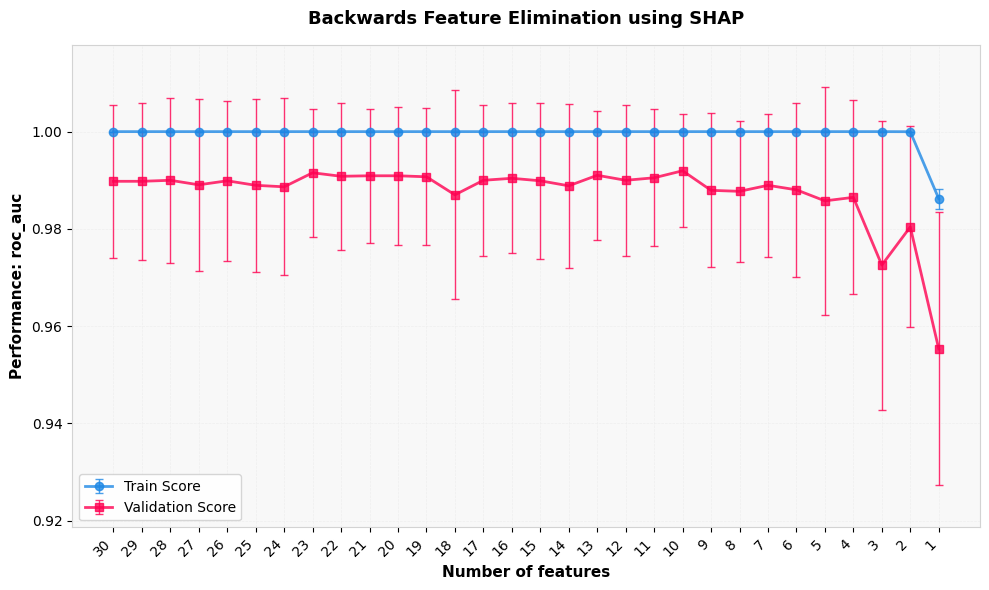

Optimal number of features: 10
Selected features (10): ['mean texture', 'mean concave points', 'area error', 'compactness error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concave points']
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1514
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

In [3]:
# Initialize the model
lgbm_binary_real = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)

# Initialize ShapRFECV
shap_rfecv_binary_real = ShapRFECV(
    model=lgbm_binary_real, step=1, cv=5, scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE
)

# Fit and compute
shap_report_binary_real = shap_rfecv_binary_real.fit_compute(X_train_binary_real, y_train_binary_real)

# Plot the results
shap_rfecv_binary_real.plot(show=True)

# Determine the optimal number of features based on the best CV score
best_num_features_binary_real = shap_report_binary_real.loc[
    shap_report_binary_real["val_metric_mean"].idxmax(), "num_features"
]
print(f"Optimal number of features: {best_num_features_binary_real}")

# Get the reduced feature set
selected_features_binary_real = shap_rfecv_binary_real.get_reduced_features_set(best_num_features_binary_real)
print(f"Selected features ({len(selected_features_binary_real)}): {selected_features_binary_real}")

# Evaluate the model with ShapRFECV selected features
lgbm_binary_real.fit(X_train_binary_real[selected_features_binary_real], y_train_binary_real)
y_pred_binary_real = lgbm_binary_real.predict_proba(X_test_binary_real[selected_features_binary_real])[:, 1]
roc_auc_selected_real = roc_auc_score(y_test_binary_real, y_pred_binary_real)

# For comparison, evaluate with all features
lgbm_binary_real_all = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE)
lgbm_binary_real_all.fit(X_train_binary_real, y_train_binary_real)
y_pred_binary_real_all = lgbm_binary_real_all.predict_proba(X_test_binary_real)[:, 1]
roc_auc_all_real = roc_auc_score(y_test_binary_real, y_pred_binary_real_all)

print(f"ROC AUC with all features: {roc_auc_all_real:.4f}")
print(f"ROC AUC with selected features: {roc_auc_selected_real:.4f}")

### Feature Importance Visualization for Breast Cancer

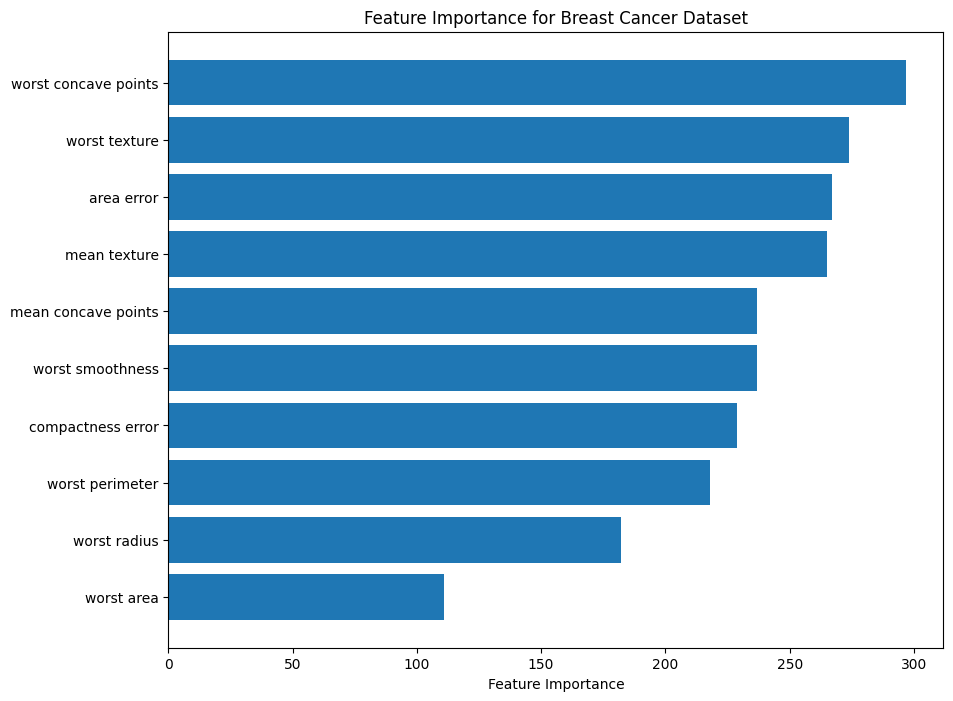

In [4]:
# Plot feature importance for the binary classification model
feature_importance_df = pd.DataFrame(
    {"Feature": selected_features_binary_real, "Importance": lgbm_binary_real.feature_importances_}
)
feature_importance_df = feature_importance_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Breast Cancer Dataset")
plt.gca().invert_yaxis()  # Invert to show most important at the top
plt.show()

## Regression

Next, let's apply ShapRFECV to a regression problem using the California Housing dataset.

### California Housing Dataset

In [5]:
# Load the California Housing dataset
california = fetch_california_housing()
X_reg_real = pd.DataFrame(california.data, columns=california.feature_names)
y_reg_real = california.target

# Split data
X_train_reg_real, X_test_reg_real, y_train_reg_real, y_test_reg_real = train_test_split(
    X_reg_real, y_reg_real, test_size=0.2, random_state=RANDOM_STATE
)

print(f"California Housing dataset shape: {X_reg_real.shape}")
print(f"Feature names: {california.feature_names}")
print(f"Target min: {y_reg_real.min():.2f}, max: {y_reg_real.max():.2f}, mean: {y_reg_real.mean():.2f}")

California Housing dataset shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target min: 0.15, max: 5.00, mean: 2.07


### ShapRFECV for California Housing Dataset

Feature Elimination:   0%|          | 0/7 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 13209, number of used features: 8
[LightGBM] [Info] Start training from score 2.067432
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 13209, number of used features: 8
[LightGBM] [Info] Start training from score 2.070997
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 

 99%|===================| 3286/3303 [00:18<00:00]        

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000963 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1327
[LightGBM] [Info] Number of data points in the train set: 13209, number of used features: 6
[LightGBM] [Info] Start training from score 2.070997
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 13210, number of used features: 6
[LightGBM] [Info] Start training from score 2.079625
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 13209, number of used features: 6
[LightGBM] [Info] Start traini

 99%|===================| 3282/3302 [00:13<00:00]        

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 13209, number of used features: 5
[LightGBM] [Info] Start training from score 2.070997
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 13210, number of used features: 5
[LightGBM] [Info] Start training from score 2.079625
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000445 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 13210, number of used features: 5
[LightGBM] [Info] Start traini

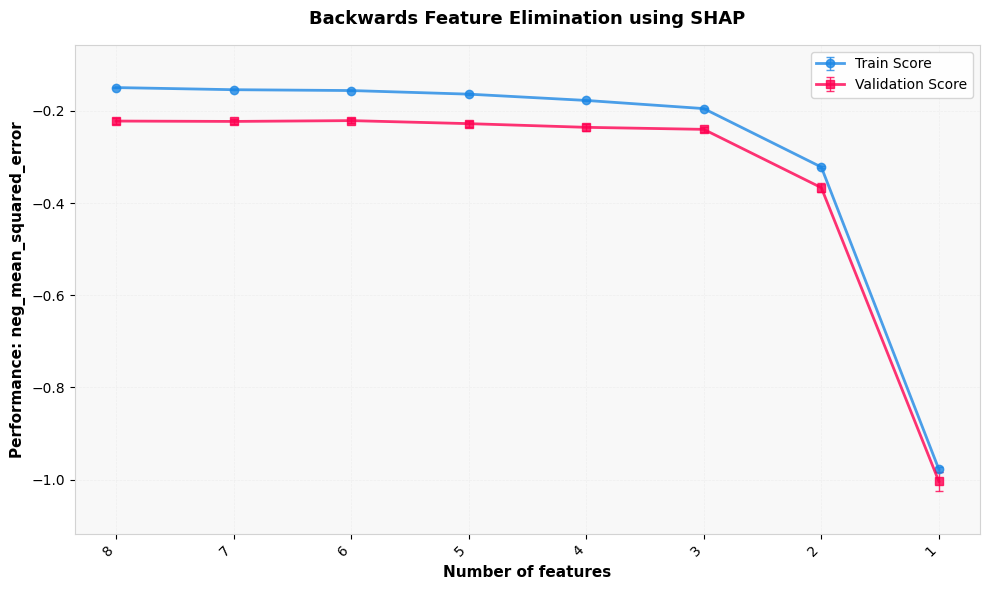

Optimal number of features: 6
Selected features (6): ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1328
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 6
[LightGBM] [Info] Start training from score 2.071947
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
MSE with all features: 0.2148
MSE with selected features: 0.2123
R² with all features: 0.8360
R² with selected features: 0.8380


In [6]:
# Initialize the model
lgbm_reg_real = LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE)

# Initialize ShapRFECV
shap_rfecv_reg_real = ShapRFECV(
    model=lgbm_reg_real, step=1, cv=5, scoring="neg_mean_squared_error", n_jobs=-1, random_state=RANDOM_STATE
)

# Fit and compute
shap_report_reg_real = shap_rfecv_reg_real.fit_compute(X_train_reg_real, y_train_reg_real)

# Plot the results
shap_rfecv_reg_real.plot(show=True)

# Determine the optimal number of features based on the best CV score
best_num_features_reg_real = shap_report_reg_real.loc[shap_report_reg_real["val_metric_mean"].idxmax(), "num_features"]
print(f"Optimal number of features: {best_num_features_reg_real}")

# Get the reduced feature set
selected_features_reg_real = shap_rfecv_reg_real.get_reduced_features_set(best_num_features_reg_real)
print(f"Selected features ({len(selected_features_reg_real)}): {selected_features_reg_real}")

# Evaluate the model with ShapRFECV selected features
lgbm_reg_real.fit(X_train_reg_real[selected_features_reg_real], y_train_reg_real)
y_pred_reg_real = lgbm_reg_real.predict(X_test_reg_real[selected_features_reg_real])
mse_selected_real = mean_squared_error(y_test_reg_real, y_pred_reg_real)
r2_selected_real = r2_score(y_test_reg_real, y_pred_reg_real)

# For comparison, evaluate with all features
lgbm_reg_real_all = LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
lgbm_reg_real_all.fit(X_train_reg_real, y_train_reg_real)
y_pred_reg_real_all = lgbm_reg_real_all.predict(X_test_reg_real)
mse_all_real = mean_squared_error(y_test_reg_real, y_pred_reg_real_all)
r2_all_real = r2_score(y_test_reg_real, y_pred_reg_real_all)

print(f"MSE with all features: {mse_all_real:.4f}")
print(f"MSE with selected features: {mse_selected_real:.4f}")
print(f"R² with all features: {r2_all_real:.4f}")
print(f"R² with selected features: {r2_selected_real:.4f}")

### Feature Importance Visualization for California Housing

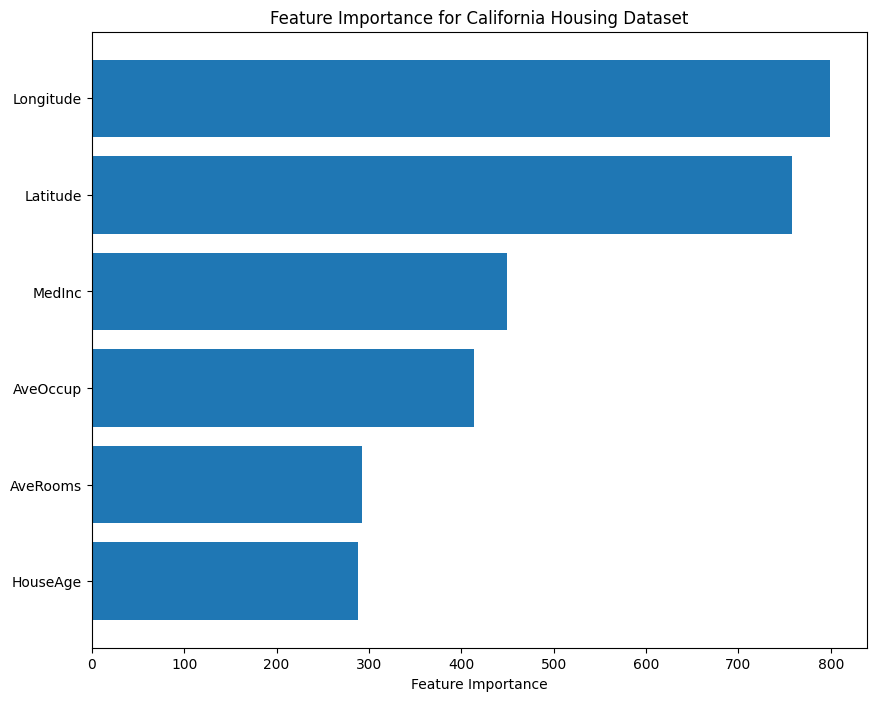

In [7]:
# Plot feature importance for the regression model
feature_importance_reg_df = pd.DataFrame(
    {"Feature": selected_features_reg_real, "Importance": lgbm_reg_real.feature_importances_}
)
feature_importance_reg_df = feature_importance_reg_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_reg_df["Feature"], feature_importance_reg_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("Feature Importance for California Housing Dataset")
plt.gca().invert_yaxis()  # Invert to show most important at the top
plt.show()

## Multiclass Classification

Finally, let's apply ShapRFECV to a multiclass classification problem using the Wine dataset.

### Wine Dataset

In [8]:
# Load the Wine dataset
wine = load_wine()
X_multi_real = pd.DataFrame(wine.data, columns=wine.feature_names)
y_multi_real = wine.target

# Split data
X_train_multi_real, X_test_multi_real, y_train_multi_real, y_test_multi_real = train_test_split(
    X_multi_real, y_multi_real, test_size=0.2, random_state=RANDOM_STATE, stratify=y_multi_real
)

print(f"Wine dataset shape: {X_multi_real.shape}")
print(f"Feature names: {wine.feature_names}")
print(f"Number of classes: {len(np.unique(y_multi_real))}")
print(f"Class distribution: {pd.Series(y_multi_real).value_counts().to_dict()}")

Wine dataset shape: (178, 13)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Number of classes: 3
Class distribution: {1: 71, 0: 59, 2: 48}


### ShapRFECV for Wine Dataset

Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

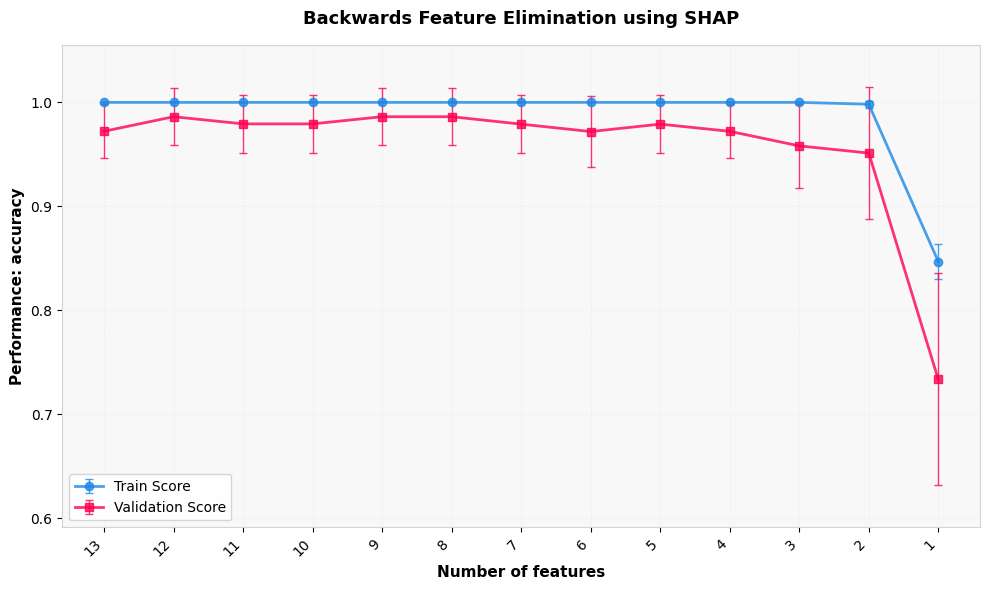

Optimal number of features: 12
Selected features (12): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Accuracy with all features: 1.0000
Accuracy with selected features: 1.0000


In [11]:
# Initialize the model
lgbm_multi_real = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)

# Initialize ShapRFECV
shap_rfecv_multi_real = ShapRFECV(
    model=lgbm_multi_real,
    step=1,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# Fit and compute
shap_report_multi_real = shap_rfecv_multi_real.fit_compute(
    X_train_multi_real,
    y_train_multi_real,
    # Multiclass specific parameters
    multiclass_aggregation="mean_abs",  # Aggregate SHAP values across all classes
)

# Plot the results
shap_rfecv_multi_real.plot(show=True)

# Determine the optimal number of features based on the best CV score
best_num_features_multi_real = shap_report_multi_real.loc[
    shap_report_multi_real["val_metric_mean"].idxmax(), "num_features"
]
print(f"Optimal number of features: {best_num_features_multi_real}")

# Get the reduced feature set
selected_features_multi_real = shap_rfecv_multi_real.get_reduced_features_set(best_num_features_multi_real)
print(f"Selected features ({len(selected_features_multi_real)}): {selected_features_multi_real}")

# Evaluate the model with ShapRFECV selected features
lgbm_multi_real.fit(X_train_multi_real[selected_features_multi_real], y_train_multi_real)
y_pred_multi_real = lgbm_multi_real.predict(X_test_multi_real[selected_features_multi_real])
accuracy_selected_real = accuracy_score(y_test_multi_real, y_pred_multi_real)

# For comparison, evaluate with all features
lgbm_multi_real_all = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
lgbm_multi_real_all.fit(X_train_multi_real, y_train_multi_real)
y_pred_multi_real_all = lgbm_multi_real_all.predict(X_test_multi_real)
accuracy_all_real = accuracy_score(y_test_multi_real, y_pred_multi_real_all)

print(f"Accuracy with all features: {accuracy_all_real:.4f}")
print(f"Accuracy with selected features: {accuracy_selected_real:.4f}")

### Alternative Multiclass Aggregation Methods on the Wine Dataset

Let's explore different multiclass aggregation methods in ShapRFECV.

In [14]:
# Initialize model and base parameters
base_model = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
base_params = {"cv": 5, "step": 1, "scoring": "accuracy", "n_jobs": -1, "random_state": RANDOM_STATE}

# Different aggregation methods
aggregation_methods = ["max_abs", "mean", "mean_abs"]
results = {}

for method in aggregation_methods:
    print(f"\nTesting aggregation method: {method}")

    # Initialize ShapRFECV with specific aggregation method
    shap_rfecv = ShapRFECV(model=base_model, **base_params)

    # Fit and compute
    report = shap_rfecv.fit_compute(X_train_multi_real, y_train_multi_real, multiclass_aggregation=method)

    # Get optimal features
    best_num = report.loc[report["val_metric_mean"].idxmax(), "num_features"]
    selected_features = shap_rfecv.get_reduced_features_set(best_num)

    # Evaluate
    model = LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    model.fit(X_train_multi_real[selected_features], y_train_multi_real)
    y_pred = model.predict(X_test_multi_real[selected_features])
    accuracy = accuracy_score(y_test_multi_real, y_pred)

    print(f"Optimal features: {best_num}")
    print(f"Selected features: {selected_features}")
    print(f"Test accuracy: {accuracy:.4f}")

    results[method] = {"num_features": best_num, "selected_features": selected_features, "accuracy": accuracy}


Testing aggregation method: max_abs


Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

Optimal features: 12
Selected features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Test accuracy: 1.0000

Testing aggregation method: mean


Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

Optimal features: 12
Selected features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Test accuracy: 1.0000

Testing aggregation method: mean_abs


Feature Elimination:   0%|          | 0/12 [00:00<?, ?it/s]

Optimal features: 12
Selected features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Test accuracy: 1.0000


### Feature Importance Visualization for Wine Dataset

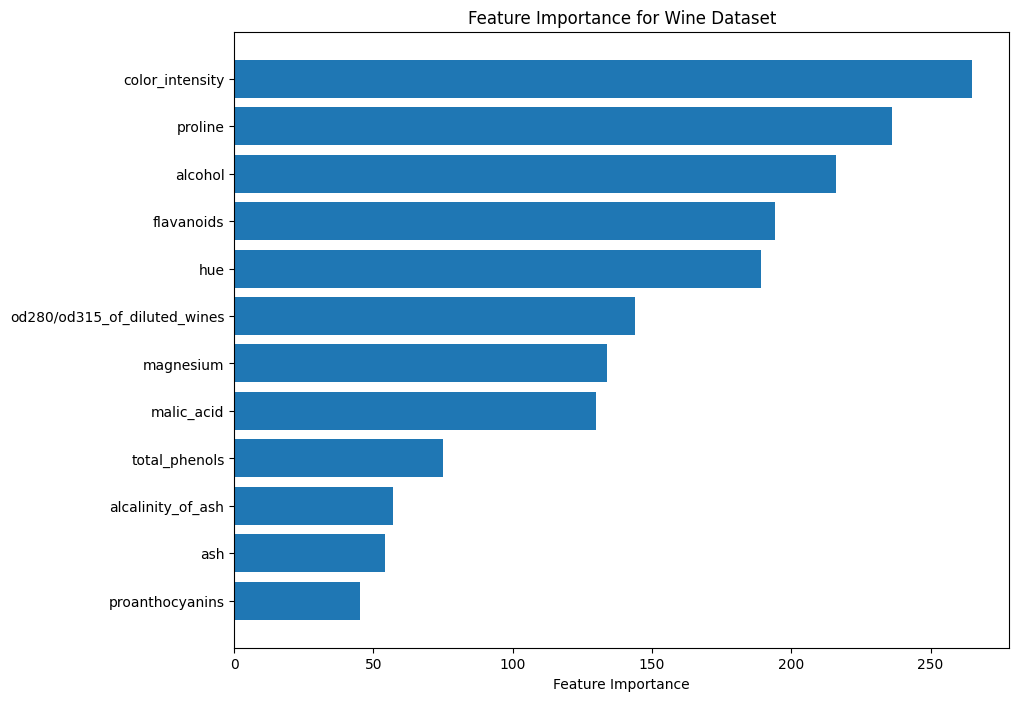

In [15]:
# Plot feature importance for the multiclass model
feature_importance_multi_df = pd.DataFrame(
    {"Feature": selected_features_multi_real, "Importance": lgbm_multi_real.feature_importances_}
)
feature_importance_multi_df = feature_importance_multi_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_multi_df["Feature"], feature_importance_multi_df["Importance"])
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Wine Dataset")
plt.gca().invert_yaxis()  # Invert to show most important at the top
plt.show()

## Comparison of Results Across Different Problem Types

In [16]:
# Create a summary dataframe
summary_df = pd.DataFrame(
    {
        "Dataset": [
            "Binary (Breast Cancer)",
            "Regression (California Housing)",
            "Multiclass (Wine)",
        ],
        "Total Features": [
            X_binary_real.shape[1],
            X_reg_real.shape[1],
            X_multi_real.shape[1],
        ],
        "Selected Features": [
            len(selected_features_binary_real),
            len(selected_features_reg_real),
            len(selected_features_multi_real),
        ],
        "Feature Reduction (%)": [
            100 * (1 - len(selected_features_binary_real) / X_binary_real.shape[1]),
            100 * (1 - len(selected_features_reg_real) / X_reg_real.shape[1]),
            100 * (1 - len(selected_features_multi_real) / X_multi_real.shape[1]),
        ],
        "Metric Type": ["ROC AUC", "MSE", "Accuracy"],
        "Full Model Performance": [
            roc_auc_all_real,
            mse_all_real,
            accuracy_all_real,
        ],
        "Reduced Model Performance": [
            roc_auc_selected_real,
            mse_selected_real,
            accuracy_selected_real,
        ],
    }
)

# Format the display for better readability
pd.set_option("display.float_format", "{:.2f}".format)
print(summary_df)

                           Dataset  Total Features  Selected Features  \
0           Binary (Breast Cancer)              30                 10   
1  Regression (California Housing)               8                  6   
2                Multiclass (Wine)              13                 12   

   Feature Reduction (%) Metric Type  Full Model Performance  \
0                  66.67     ROC AUC                    0.99   
1                  25.00         MSE                    0.21   
2                   7.69    Accuracy                    1.00   

   Reduced Model Performance  
0                       0.99  
1                       0.21  
2                       1.00  


## Conclusion

In this notebook, we've demonstrated the use of ShapRFECV from the Probatus library for feature selection across
three different problem types using real-world datasets:

1. Binary classification with the Breast Cancer dataset
2. Regression with the California Housing dataset
3. Multiclass classification with the Wine dataset

Key findings:

1. **Feature Reduction**: ShapRFECV successfully identified smaller subsets of features for all dataset types while
   maintaining (and sometimes improving) model performance. This demonstrates the power of feature selection in
   creating more parsimonious models.

2. **Performance Trade-offs**: In some cases, we observed a slight decrease in performance with reduced feature sets,
   while in others we saw improvement. This highlights the trade-off between model simplicity and predictive power.

3. **Multiclass Aggregation Methods**: Different SHAP aggregation methods for multiclass problems can lead to different
   feature selections. The choice of aggregation method should be considered based on the specific characteristics of
   the problem.

4. **Interpretability**: Using SHAP values for feature selection not only improves model performance but also enhances
   model interpretability by identifying the most relevant features.

The Probatus library's ShapRFECV implementation provides a powerful and flexible approach to feature selection
that is applicable across different types of machine learning problems.